# 📊 EDA — ESA Satellite Test SOC Dataset

**File:** `esa_eo4_test_soc.csv`  
**Rows:** 7,138 | **Columns:** 226  
**Description:** Test set for the ESA EO4 SOC prediction task. Same features as training set **minus the target** (`logoc_d.f`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load Data


In [2]:
from pathlib import Path
raw = Path('../data/raw')
df_test = pd.read_csv(raw / 'esa_eo4_test_soc.csv')
df_train = pd.read_csv(raw / 'esa_eo4_train_soc.csv')
print(f"Test shape:  {df_test.shape}")
print(f"Train shape: {df_train.shape}")
print(f"\nColumns in train but not test: {set(df_train.columns) - set(df_test.columns)}")
print(f"Columns in test but not train: {set(df_test.columns) - set(df_train.columns)}")
df_test.head()


Test shape:  (7138, 226)
Train shape: (23898, 227)

Columns in train but not test: {'logoc_d.f'}
Columns in test but not train: set()


,olc_id,UUID,X,Y,observation_year,hzn_top,hzn_bot,bioclim.var_chelsa.bio12_m_1km_s_1981_2010_go_epsg.4326_v20231002,bioclim.var_chelsa.bio13_m_1km_s_1981_2010_go_epsg.4326_v20231002,bioclim.var_chelsa.bio16_m_1km_s_1981_2010_go_epsg.4326_v20231002,...,veg_evi_mod13q1.v061_sd_250m_s0..0cm__v1.0,wetlands.cw_upmc.wtd_c_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wetlands.groundwater-driven_upmc.wtd_p_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wetlands.permanent_upmc.wtd_p_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wetlands.regularly-flooded_upmc.wtd_p_250m_b0..200cm_2010_2015_go_epsg.4326_v20231002,wv_mcd19a2v061.seasconv.m.yearly_p25_1km_s_0101_1231_go_epsg.4326_v20230619,wv_mcd19a2v061.seasconv.m.yearly_p50_1km_s_0101_1231_go_epsg.4326_v20230619,wv_mcd19a2v061.seasconv.m.yearly_p75_1km_s_0101_1231_go_epsg.4326_v20230619,wv_mcd19a2v061.seasconv.m.yearly_sd_1km_s_0101_1231_go_epsg.4326_v20230619,sample_id
0,868F4F8F+GXM,b17f30d4-b862-11ee-843e-0242ac110004,4.881052e+05,1.465831e+06,2011,4.0,110.0,12905,1329,3737,...,2305,0,15,0,0,875,1407,2418,1170,42384
1,85MF3WQF+MC9,b17dc5dc-b862-11ee-843e-0242ac110004,-1.135814e+06,2.316936e+06,2006,130.0,160.0,5993,732,1829,...,374,0,25,0,0,357,422,551,180,49785
2,86V8MX56+X6V,b17cc57e-b862-11ee-843e-0242ac110004,2.238996e+05,2.744133e+06,2002,20.0,48.0,7351,1140,3184,...,704,0,2,0,0,441,657,1749,770,47076
3,76X4XC64+FG3,b17e349a-b862-11ee-843e-0242ac110004,-1.536711e+05,7.663498e+05,2008,142.0,166.0,9289,1231,2803,...,882,0,4,0,0,970,1405,2649,905,11252
4,86437X3R+4GF,b17ee836-b862-11ee-843e-0242ac110004,-1.882943e+05,1.021947e+06,2010,0.0,12.0,8831,1171,3016,...,438,0,0,0,0,912,1535,2792,1075,11044


## 2. Basic Information


In [3]:
df_test.info(verbose=False, show_counts=True)
print(f"\nMemory: {df_test.memory_usage(deep=True).sum()/1e6:.1f} MB")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7138 entries, 0 to 7137
Columns: 226 entries, olc_id to sample_id
dtypes: float64(4), int64(220), object(2)
memory usage: 12.3+ MB

Memory: 13.9 MB


In [4]:
df_test.describe().T.head(15)


,count,mean,std,min,25%,50%,75%,max
X,7138.0,-3.415789e+05,1.215603e+06,-2.349668e+06,-1.491024e+06,-9.085167e+04,6.277267e+05,2.255345e+06
Y,7138.0,1.999011e+06,5.396976e+05,3.790418e+05,1.716360e+06,1.975367e+06,2.376981e+06,3.134435e+06
observation_year,7138.0,2.012094e+03,6.058043e+00,2.001000e+03,2.008000e+03,2.012000e+03,2.017000e+03,2.021000e+03
hzn_top,7138.0,4.389115e+01,5.489595e+01,0.000000e+00,5.000000e+00,3.000000e+01,6.600000e+01,1.442000e+03
hzn_bot,7138.0,6.864434e+01,6.252063e+01,4.000000e+00,2.700000e+01,5.200000e+01,9.900000e+01,1.460000e+03
bioclim.var_chelsa.bio12_m_1km_s_1981_2010_go_epsg.4326_v20231002,7138.0,9.477740e+03,4.691693e+03,7.210000e+02,5.635000e+03,9.360000e+03,1.215800e+04,4.023300e+04
bioclim.var_chelsa.bio13_m_1km_s_1981_2010_go_epsg.4326_v20231002,7138.0,1.351872e+03,7.957430e+02,1.230000e+02,9.400000e+02,1.201000e+03,1.421000e+03,6.286000e+03
bioclim.var_chelsa.bio16_m_1km_s_1981_2010_go_epsg.4326_v20231002,7138.0,3.691115e+03,2.134380e+03,3.150000e+02,2.546000e+03,3.395000e+03,3.930000e+03,1.848300e+04
bioclim.var_chelsa.bio2_m_1km_s_1981_2010_go_epsg.4326_v20231002,7138.0,1.046180e+02,1.959728e+01,1.200000e+01,9.500000e+01,1.020000e+02,1.180000e+02,1.580000e+02
bioclim.var_chelsa.bio3_m_1km_s_1981_2010_go_epsg.4326_v20231002,7138.0,3.182792e+02,7.205601e+01,1.110000e+02,2.710000e+02,3.010000e+02,3.690000e+02,5.330000e+02


## 3. Missing Values


In [5]:
missing = df_test.isnull().sum().sum()
print(f"Total missing values: {missing}")
if missing == 0:
  print(" No missing values!")


Total missing values: 0
✅ No missing values!


## 4. Train vs Test Distribution Comparison

Critical check: are train and test drawn from the same distribution?


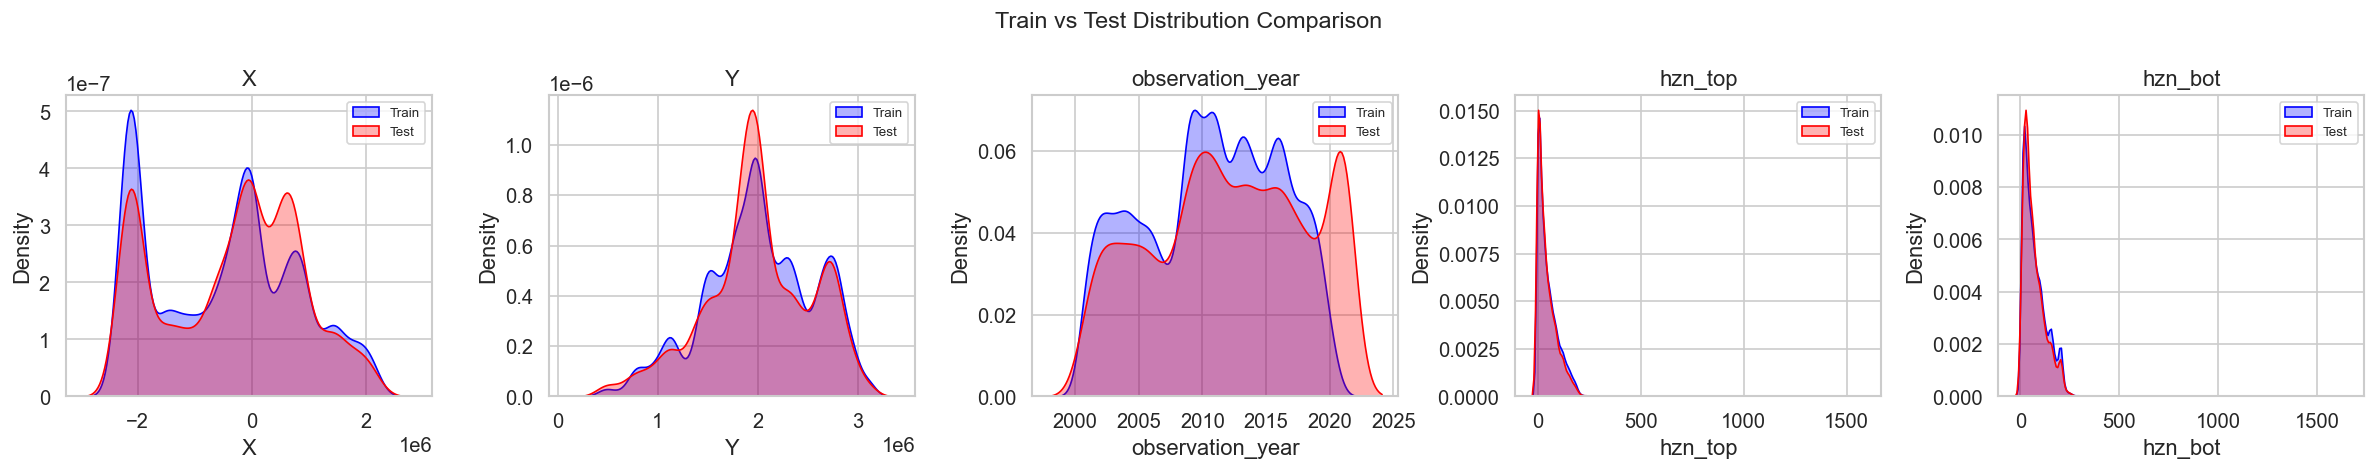

In [6]:
# Compare key feature distributions
compare_cols = ['X', 'Y', 'observation_year', 'hzn_top', 'hzn_bot']
fig, axes = plt.subplots(1, len(compare_cols), figsize=(20, 4))

for i, col in enumerate(compare_cols):
    sns.kdeplot(df_train[col], ax=axes[i], label='Train', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(df_test[col], ax=axes[i], label='Test', color='red', fill=True, alpha=0.3)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Train vs Test Distribution Comparison', fontsize=14)
plt.tight_layout()
plt.show()


In [7]:
# Compare descriptive stats side by side for a subset
common_numeric = [c for c in df_test.select_dtypes(np.number).columns if c in df_train.columns][:20]
comp = pd.DataFrame({
    'train_mean': df_train[common_numeric].mean(),
    'test_mean': df_test[common_numeric].mean(),
    'train_std': df_train[common_numeric].std(),
    'test_std': df_test[common_numeric].std(),
})
comp['mean_diff_%'] = ((comp['test_mean'] - comp['train_mean']) / comp['train_mean'].abs().clip(lower=1e-6) * 100).round(2)
comp.sort_values('mean_diff_%', key=abs, ascending=False)


,train_mean,test_mean,train_std,test_std,mean_diff_%
X,-4.773692e+05,-3.415789e+05,1.275797e+06,1.215603e+06,28.45
hzn_top,4.897853e+01,4.389115e+01,6.027348e+01,5.489595e+01,-10.39
hzn_bot,7.379283e+01,6.864434e+01,6.862599e+01,6.252063e+01,-6.98
bsi_glad.SeasConv.ard2_m_30m_s_0501_0630_go_epsg.4326_v20230908,9.340028e+00,9.763099e+00,2.587005e+00,2.586933e+00,4.53
bsf_glad.SeasConv.ard2_m_30m_s_go_epsg.4326_v20230908,7.752992e+00,7.465677e+00,1.728115e+01,1.895489e+01,-3.71
blue_glad.SeasConv.ard2_m_30m_s_1101_1231_go_epsg.4326_v20230908,1.041861e+01,1.077599e+01,9.254914e+00,9.362268e+00,3.43
blue_glad.SeasConv.ard2_m_30m_s_0301_0430_go_epsg.4326_v20230908,1.397531e+01,1.352648e+01,1.821860e+01,1.659448e+01,-3.21
blue_glad.SeasConv.ard2_m_30m_s_0101_0228_go_epsg.4326_v20230908,1.482697e+01,1.530120e+01,2.013653e+01,2.125099e+01,3.20
blue_glad.SeasConv.ard2_m_30m_s_0701_0831_go_epsg.4326_v20230908,9.568583e+00,9.291398e+00,5.888106e+00,5.442734e+00,-2.90
bsi_glad.SeasConv.ard2_m_30m_s_0301_0430_go_epsg.4326_v20230908,9.154323e+00,9.401653e+00,2.871149e+00,4.047142e+00,2.70


## 5. Spatial Distribution


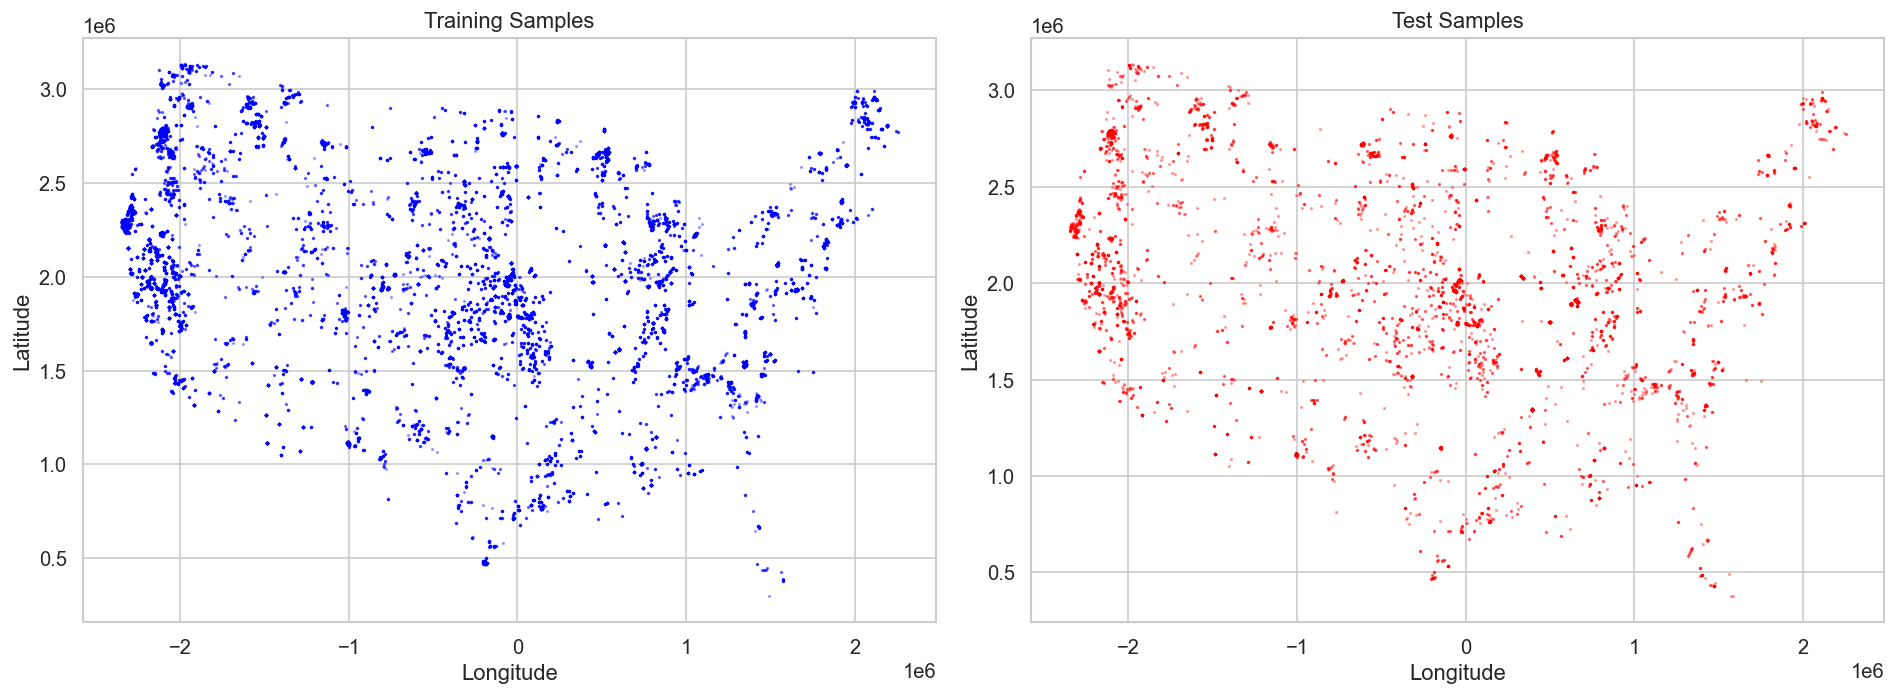

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df_train['X'], df_train['Y'], s=1, alpha=0.3, c='blue', label='Train')
axes[0].set_title('Training Samples')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

axes[1].scatter(df_test['X'], df_test['Y'], s=1, alpha=0.3, c='red', label='Test')
axes[1].set_title('Test Samples')
axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


## 6. Feature Value Ranges


In [9]:
# Check if test values fall outside training range
out_of_range = {}
for col in common_numeric:
    tr_min, tr_max = df_train[col].min(), df_train[col].max()
    te_below = (df_test[col] < tr_min).sum()
    te_above = (df_test[col] > tr_max).sum()
    if te_below + te_above > 0:
        out_of_range[col] = {'below_train_min': te_below, 'above_train_max': te_above}

if out_of_range:
    oor_df = pd.DataFrame(out_of_range).T
    print(f"Features with test values outside training range: {len(oor_df)}")
    print(oor_df.head(20))
else:
    print("All test feature values fall within training range.")


Features with test values outside training range: 4
                                                    below_train_min  \
observation_year                                                  0   
bsi_glad.SeasConv.ard2_m_30m_s_0101_0228_go_eps...                0   
bsi_glad.SeasConv.ard2_m_30m_s_0301_0430_go_eps...                0   
bsi_glad.SeasConv.ard2_m_30m_s_0501_0630_go_eps...                4   

                                                    above_train_max  
observation_year                                                975  
bsi_glad.SeasConv.ard2_m_30m_s_0101_0228_go_eps...                2  
bsi_glad.SeasConv.ard2_m_30m_s_0301_0430_go_eps...                7  
bsi_glad.SeasConv.ard2_m_30m_s_0501_0630_go_eps...                1  


## 7. Key Findings & Summary

### Dataset Summary
- **7,138 rows × 226 columns** — no missing values
- Same features as training set **except** the target `logoc_d.f` is absent
- This is the competition/evaluation test set

### Key Observations
1. **Train/Test alignment**: Compare distributions above for potential covariate shift
2. **Spatial coverage**: Check if test covers same geographic regions as train
3. **Out-of-range features**: Any features where test values exceed training bounds may need clipping

### Action Plan
- Ensure consistent preprocessing pipeline for train and test
- Monitor for distribution shifts in key features
- Use training set statistics (mean, std) for normalisation
